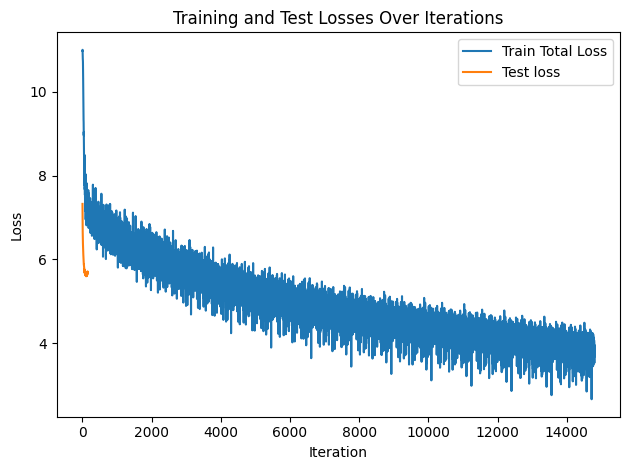

In [7]:
import pickle
import matplotlib.pyplot as plt

# Load recorded metrics
with open('metrics1.pkl', 'rb') as f:
    metrics = pickle.load(f)

iters = metrics['iter']
# plt.plot(iters, metrics['train_main'], label='Train Main Loss')
# plt.plot(iters[200:], metrics['train_balance'][200:], label='Train Balance Loss')
plt.plot(iters, metrics['train_total'], label='Train Total Loss')
plt.plot(iters[:len(metrics['test_loss'])], metrics['test_loss'], label='Test loss')

# Test losses occur every `log_interval` iterations
log_interval = 2000
# num_test = len(metrics['test_loss'])
# if num_test > 0:
#     test_iters = [log_interval * i for i in range(1, num_test + 1)]
#     plt.plot(test_iters, metrics['test_loss'], 'o-', label='Test Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Losses Over Iterations')
plt.tight_layout()
plt.show()

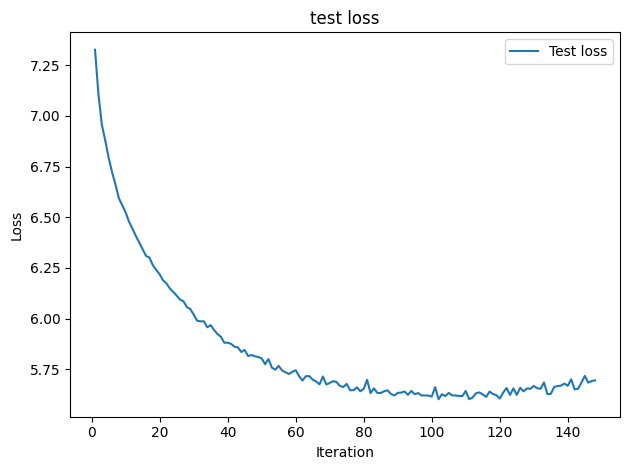

In [2]:
plt.plot(iters[:len(metrics['test_loss'])], metrics['test_loss'], label='Test loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('test loss')
plt.tight_layout()
plt.show()

In [1]:
import os
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
from torch.utils.data.dataset import IterableDataset
from tqdm import tqdm
from my_gate import MyGate

from fmoe.transformer import FMoETransformerMLP
from fmoe.gates import NaiveGate

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})

class WikiText103LMIterable(IterableDataset):
    def __init__(self, split="train", seq_len=40):
        super().__init__()
        self.seq_len = seq_len
        self.raw_ds = load_dataset(
            "wikitext", "wikitext-103-raw-v1", split=split, streaming=True
        )

    def __iter__(self):
        buffer = []
        for example in self.raw_ds:
            text = example["text"]
            if not text or text.isspace():
                continue
            ids = tokenizer.encode(text, add_special_tokens=False)
            buffer.extend(ids)
            while len(buffer) >= self.seq_len + 1:
                chunk = buffer[: self.seq_len + 1]
                buffer = buffer[self.seq_len + 1 :]
                inp = torch.tensor(chunk[:-1], dtype=torch.long)
                tgt = torch.tensor(chunk[1:], dtype=torch.long)
                yield inp, tgt


def create_wikitext_dataloader(batch_size=6, seq_len=40, split="train", num_workers=4):
    ds = WikiText103LMIterable(split=split, seq_len=seq_len)
    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=num_workers,
        drop_last=True,
        prefetch_factor=2,
    )

class TransformerLayer(nn.Module):
    def __init__(self, d_model, num_experts, top_k, gate_hook=None):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.moe = FMoETransformerMLP(
            num_expert=num_experts,
            d_model=d_model,
            d_hidden=d_model * 4,
            top_k=top_k,
            activation=nn.GELU(),
            expert_dp_comm="none",
            expert_rank=0,
            gate=MyGate,
            gate_hook=gate_hook
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        res = x
        x = self.norm1(x)
        attn_out, _ = self.self_attn(x, x, x)
        x = res + attn_out

        res = x
        x = self.norm2(x)
        bsz, seq_len, d_model = x.shape
        x_flat = x.view(-1, d_model)
        moe_out = self.moe(x_flat)
        moe_out = moe_out.view(bsz, seq_len, d_model)
        return res + moe_out

class TransformerWithMoE(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_layers=3, num_experts=10, top_k=2, gate_hook=None):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model,
                                      padding_idx=tokenizer.pad_token_id)
        self.pos_emb = nn.Parameter(torch.randn(1024, d_model) * 0.02)
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, num_experts, top_k, gate_hook=gate_hook)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        bsz, seq_len = x.size()
        x = self.token_emb(x) + self.pos_emb[:seq_len]
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.head(x)


/home/vasilevpa/Federated-Mixture-of-Experts-with-Personalized-Weighting/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from transformers import GPT2TokenizerFast
from train import TransformerWithMoE
from fmoe.transformer import FMoETransformerMLP
from fmoe.gates import GShardGate

def generate_text(model, tokenizer, prompt, max_new_tokens=50, device="cuda", temperature=1.0, top_k=50):
    model.eval()
    model.to(device)

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    generated = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_trim = generated[:, -1024:]  # не больше позиции pos_emb
            outputs = model(input_trim)
            logits = outputs[:, -1, :] / temperature

            if top_k > 0:
                values, indices = torch.topk(logits, top_k)
                probs = torch.zeros_like(logits).scatter_(1, indices, values)
                probs = torch.softmax(probs, dim=-1)
            else:
                probs = torch.softmax(logits, dim=-1)

            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat((generated, next_token), dim=1)

    return tokenizer.decode(generated[0], skip_special_tokens=True)


def load_model(vocab_size, checkpoint_path, device="cuda"):
    d_model = 256
    num_layers = 3
    top_k = 2
    num_experts_per_device = 5
    world_size = 2
    total_experts = num_experts_per_device * world_size

    model = TransformerWithMoE(vocab_size, d_model, num_layers, total_experts, top_k)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    return model


def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({"pad_token": "[PAD]"})

    vocab_size = tokenizer.vocab_size + 1  # pad_token добавлен

    checkpoint_path = "checkpoint_epoch_5.pt"  # путь к сохранённому чекпоинту
    model = load_model(vocab_size, checkpoint_path, device=device)

    prompt = "My name is"
    generated_text = generate_text(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        max_new_tokens=20,
        device=device,
        temperature=2.,
        top_k=5
    )

    print("\n📝 Generated text:")
    print(generated_text)


if __name__ == "__main__":
    main()


Config: 10 experts, vocab_size=50258
Model parameters: 42,612,336


Epoch 1: 0it [00:00, ?it/s]

torch.Size([1]) torch.Size([]) torch.Size([])


Epoch 1: 2it [00:10,  4.55s/it, main=10.9463, bal=0.000000, total=10.9135]

torch.Size([1]) torch.Size([]) torch.Size([])
torch.Size([1]) torch.Size([]) torch.Size([])


...

Epoch 1: 92it [00:27,  5.26it/s, main=7.5227, bal=0.000000, total=-10.9420]

torch.Size([1]) torch.Size([]) torch.Size([])
torch.Size([1]) torch.Size([]) torch.Size([])


Epoch 1: 93it [00:28,  3.31it/s, main=7.6056, bal=0.000000, total=-11.4009]


torch.Size([1]) torch.Size([]) torch.Size([])


KeyboardInterrupt: 